<a href="https://colab.research.google.com/github/Toiati-salah-eddine-001/Deep_Learning_G/blob/main/CNNTEST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from keras import Sequential
from keras.layers import Conv2D , Flatten , MaxPooling2D , Dense,Input,Dropout,BatchNormalization
from keras.callbacks import EarlyStopping

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
assert x_train.shape == (50000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 577s 3us/step


In [4]:
print(f"x_train:{x_train.shape}")
print(f"x_train:{x_train.ndim}")
print(f"y_train:{y_train.shape}")
print(f"y_train:{y_train.ndim}")
print(f"x_test:{x_test.shape}")
print(f"y_test:{y_test.shape}")

NameError: name 'x_train' is not defined

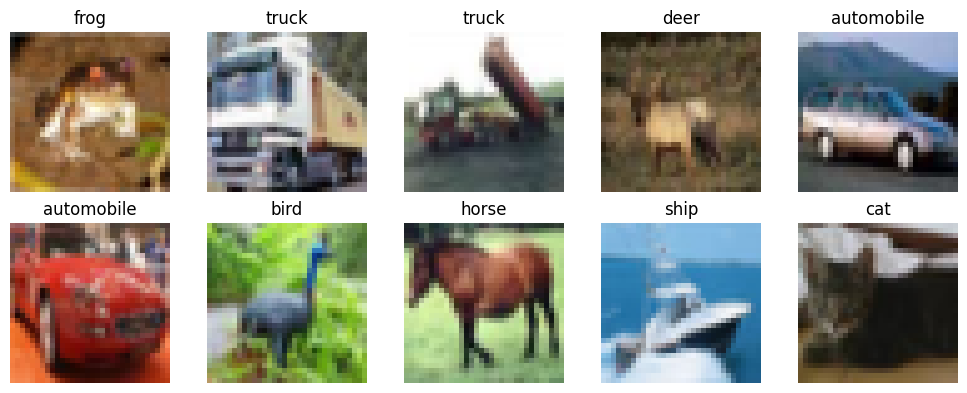

In [ ]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# normalization_layer = tf.keras.layers.Rescaling(1./255)
# x_train_normalize=normalization_layer(x_train)
# x_test_normalize=normalization_layer(x_test)
# print(f"x_train avant:{x_train[2,:]}")
# print(f"x_train apret:{x_train_normalize[2,:]}")
# print(f"x_test avant:{x_test[2,:]}")
# print(f"x_test apret:{x_test_normalize[2,:]}")
# or
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0

# Encodage des labels en one-hot
print(f"y_train befor:{y_train.shape}")
print(f"y_train befor:{y_train[:2]}")
from tensorflow.keras.utils import to_categorical
y_train=to_categorical(y_train)
y_test=to_categorical(y_test)
print(f"y_train after:{y_train.shape}")
print(f"y_train after:{y_train[:2]}")

y_train befor:(50000, 1)
y_train befor:[[6]
 [9]]
y_train after:(50000, 10)
y_train after:[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [ ]:
print(f"y_test after:{y_test.shape}")

y_test after:(10000, 10)


In [ ]:
# model l'architecture du CNN
model = keras.Sequential([
    Input(shape=(32,32,3)),
    Conv2D(32,kernel_size=(2,2),activation="relu",input_shape=(256,256,3)),
    # BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(32,kernel_size=(2,2),activation="relu"),
    # BatchNormalization(),
    MaxPooling2D((2,2)),

])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 31, 31, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,544 (17.75 KB)

 Trainable params: 4,544 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(Flatten())
model.add(Dense(64,activation='relu'))
# model.add(Dropout(0.1))
model.add(Dense(10,activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 31, 31, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,610 (412.54 KB)

 Trainable params: 105,610 (412.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compiler le modèle
model.compile(optimizer="adam",loss='categorical_crossentropy',metrics=['accuracy'])


In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
# entraîner le modèle
history=model.fit(x_train,
                  y_train,
                  epochs=10,
                  batch_size=64,
                  validation_split=0.2,
                  callbacks=[early_stopping],
                  verbose=1
    )

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.4024 - loss: 1.6610 - val_accuracy: 0.4980 - val_loss: 1.4142
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.5251 - loss: 1.3374 - val_accuracy: 0.5584 - val_loss: 1.2593
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.5717 - loss: 1.2146 - val_accuracy: 0.5926 - val_loss: 1.1712
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.5984 - loss: 1.1411 - val_accuracy: 0.6063 - val_loss: 1.1311
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.6206 - loss: 1.0798 - val_accuracy: 0.6173 - val_loss: 1.1112
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.6374 - loss: 1.0334 - val_accuracy: 0.6316 - val_loss: 1.0624
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.6511 - loss: 0.9883 - val_accuracy: 0.6320 - val_loss: 1.0630
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.6653 - loss: 0.9530 - 

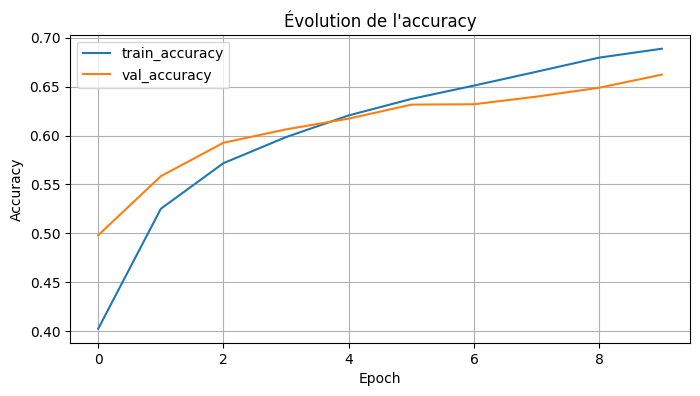

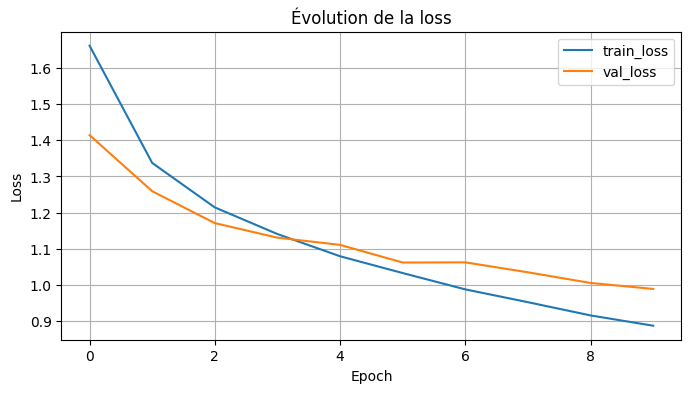

In [ ]:

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title("Évolution de l'accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Évolution de la loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## ways to reduce overfitting

- Add more data
- Data Augmentation
- L1/L2 Regularizer
- Dropout
- Batch Norm
- Reduce complexity

In [ ]:
# évaluer le modèle sur x_test, y_test
loss,accuracy=model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6541 - loss: 0.9960


In [ ]:
print(f"Accuracy test : {accuracy * 100:.2f}%")

Accuracy test : 65.41%


Classe réelle  : airplane
Classe prédite : ship


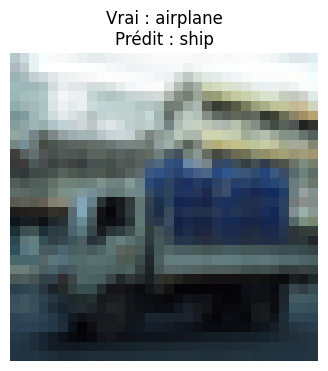

In [ ]:
y_test_labels = y_test.copy()
# faire une prédiction sur une image aléatoire
index = random.randint(0, len(x_test) - 1)
predection=model.predict(np.expand_dims(x_test[index], axis=0), verbose=0)

pred_label=int(np.argmax(predection))
true_label = int(y_test_labels[index][0])
confidence = float(np.max(predection))

print("Classe réelle  :", class_names[true_label])
print("Classe prédite :", class_names[pred_label])

plt.figure(figsize=(4, 4))
plt.imshow(x_test[index])
plt.title(f"Vrai : {class_names[true_label]}\nPrédit : {class_names[pred_label]}")
plt.axis('off')
plt.show()